<a href="https://colab.research.google.com/github/XeyadO/FL-GIU/blob/main/autism_svm_FL1XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# STEP 1: MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# STEP 2: IMPORT LIBRARIES
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# STEP 3: SET DATA PATH
data_dir = "/content/drive/MyDrive/Bachelor_ds"
img_size = (224, 224)

# STEP 4: LOAD IMAGES AND LABELS
images = []
labels = []

for label in os.listdir(data_dir):
    label_dir = os.path.join(data_dir, label)
    for img_file in os.listdir(label_dir):
        img_path = os.path.join(label_dir, img_file)
        try:
            img = load_img(img_path, target_size=img_size)
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(label)
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

images = np.array(images)
labels = np.array(labels)

print(f"Loaded {len(images)} images.")

# STEP 5: ENCODE LABELS
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

Error loading image /content/drive/MyDrive/Bachelor_ds/consolidated/Autistic: [Errno 21] Is a directory: '/content/drive/MyDrive/Bachelor_ds/consolidated/Autistic'
Error loading image /content/drive/MyDrive/Bachelor_ds/consolidated/Non_Autistic: [Errno 21] Is a directory: '/content/drive/MyDrive/Bachelor_ds/consolidated/Non_Autistic'
Error loading image /content/drive/MyDrive/Bachelor_ds/valid/Non_Autistic: [Errno 21] Is a directory: '/content/drive/MyDrive/Bachelor_ds/valid/Non_Autistic'
Error loading image /content/drive/MyDrive/Bachelor_ds/valid/Autistic: [Errno 21] Is a directory: '/content/drive/MyDrive/Bachelor_ds/valid/Autistic'
Error loading image /content/drive/MyDrive/Bachelor_ds/Alzheimer_ds/NonDemented: [Errno 21] Is a directory: '/content/drive/MyDrive/Bachelor_ds/Alzheimer_ds/NonDemented'
Error loading image /content/drive/MyDrive/Bachelor_ds/Alzheimer_ds/VeryMildDemented: [Errno 21] Is a directory: '/content/drive/MyDrive/Bachelor_ds/Alzheimer_ds/VeryMildDemented'
Error 

In [27]:
# STEP 6: FEATURE EXTRACTION USING MOBILE NET
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
images_preprocessed = preprocess_input(images)
features = base_model.predict(images_preprocessed, batch_size=32, verbose=1)

# STEP 7: SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(features, labels_encoded, test_size=0.2, random_state=42)

# STEP 8: TRAIN SVM MODEL
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

89/89 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step


SVC(kernel='linear')

In [28]:
                                                                                                                              # STEP 9: EVALUATE MODEL
y_pred = svm_model.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Confusion Matrix:
[[ 10  46]
 [ 84 428]]

Classification Report:
              precision    recall  f1-score   support

        test       0.11      0.18      0.13        56
       train       0.90      0.84      0.87       512

    accuracy                           0.77       568
   macro avg       0.50      0.51      0.50       568
weighted avg       0.82      0.77      0.80       568



In [29]:
data_dir = "/content/drive/MyDrive/Bachelor_ds/train"


In [30]:
images = []
labels = []

for img_file in os.listdir(data_dir):
    img_path = os.path.join(data_dir, img_file)
    if img_file.endswith(".jpg") or img_file.endswith(".png"):
        try:
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            images.append(img_array)

            # Extract label from filename (assumes format: Label.xxx.jpg)
            label = img_file.split('.')[0]  # Gets 'Autistic' or 'Non_Autistic'
            labels.append(label)

        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

images = np.array(images)
labels = np.array(labels)

print(np.unique(labels))  # Should show ['Autistic' 'Non_Autistic']


['Autistic' 'Non_Autistic']


In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
print(le.classes_)  # Should show ['Autistic' 'Non_Autistic']


['Autistic' 'Non_Autistic']


In [32]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
images_preprocessed = preprocess_input(images)
features = base_model.predict(images_preprocessed, batch_size=32, verbose=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, labels_encoded, test_size=0.2, random_state=42)

from sklearn.svm import SVC
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)


80/80 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step


SVC(kernel='linear')

In [33]:
test_img_path = "/content/drive/MyDrive/Bachelor_ds/test/Non_Autistic.147.jpg"

test_img = load_img(test_img_path, target_size=(224, 224))
test_img_array = img_to_array(test_img)
test_img_array = np.expand_dims(test_img_array, axis=0)
test_img_preprocessed = preprocess_input(test_img_array)

test_feature = base_model.predict(test_img_preprocessed)
predicted_label_encoded = svm_model.predict(test_feature)
predicted_label = le.inverse_transform(predicted_label_encoded)

print(f"Predicted Label: {predicted_label[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Label: Non_Autistic


In [12]:
test_img_path = "/content/drive/MyDrive/Bachelor_ds/test/Non_Autistic.144.jpg"

test_img = load_img(test_img_path, target_size=(224, 224))
test_img_array = img_to_array(test_img)
test_img_array = np.expand_dims(test_img_array, axis=0)
test_img_preprocessed = preprocess_input(test_img_array)

test_feature = base_model.predict(test_img_preprocessed)
predicted_label_encoded = svm_model.predict(test_feature)
predicted_label = le.inverse_transform(predicted_label_encoded)

print(f"Predicted Label: {predicted_label[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Predicted Label: Non_Autistic


In [13]:
test_img_path = "/content/drive/MyDrive/Bachelor_ds/test/Autistic.47.jpg"

test_img = load_img(test_img_path, target_size=(224, 224))
test_img_array = img_to_array(test_img)
test_img_array = np.expand_dims(test_img_array, axis=0)
test_img_preprocessed = preprocess_input(test_img_array)

test_feature = base_model.predict(test_img_preprocessed)
predicted_label_encoded = svm_model.predict(test_feature)
predicted_label = le.inverse_transform(predicted_label_encoded)

print(f"Predicted Label: {predicted_label[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Label: Autistic


In [34]:
# prompt: I want to calculate the accuracy precison and recall and f1 score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ... (Your existing code) ...

# STEP 9: EVALUATE MODEL
y_pred = svm_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # Use 'weighted' for multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print(f"\nAccuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# ... (Rest of your code) ...


Confusion Matrix:
[[179  71]
 [ 70 188]]

Classification Report:
              precision    recall  f1-score   support

    Autistic       0.72      0.72      0.72       250
Non_Autistic       0.73      0.73      0.73       258

    accuracy                           0.72       508
   macro avg       0.72      0.72      0.72       508
weighted avg       0.72      0.72      0.72       508


Accuracy: 0.7224409448818898
Precision: 0.7224271786931875
Recall: 0.7224409448818898
F1 Score: 0.7224312619512469


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
Predicted label: train


In [11]:
#Federated Learning


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# Function to load and preprocess images from a directory
def load_dataset(directory):
    images = []
    labels = []
    for img_file in os.listdir(directory):
        if img_file.endswith((".jpg", ".png")):
            img_path = os.path.join(directory, img_file)
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            images.append(img_array)
            label = img_file.split('.')[0]  # Extract label from filename
            labels.append(label)
    return np.array(images), np.array(labels)

# Load and preprocess training data
train_dir = "/content/drive/MyDrive/Bachelor_ds/train"
X_train, y_train = load_dataset(train_dir)
X_train = preprocess_input(X_train)
y_train = le.transform(y_train)  # Use your existing LabelEncoder

# Load and preprocess test data (for final evaluation only)
test_dir = "/content/drive/MyDrive/Bachelor_ds/test"
X_test, y_test = load_dataset(test_dir)
X_test = preprocess_input(X_test)
y_test = le.transform(y_test)

# Extract features using MobileNetV2 (for both train and test)
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
train_features = base_model.predict(X_train, batch_size=32, verbose=1)
test_features = base_model.predict(X_test, batch_size=32, verbose=1)

80/80 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


In [36]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score
import numpy as np

class FederatedSVM:
    def __init__(self, n_clients=3, n_rounds=5):
        self.n_clients = n_clients
        self.n_rounds = n_rounds
        self.global_model = SVC(kernel='linear')
        self.client_models = [clone(self.global_model) for _ in range(n_clients)]

    def split_data(self, X, y):
        # Shuffle and split data among clients
        X_shuffled, y_shuffled = shuffle(X, y, random_state=42)
        split_size = len(X) // self.n_clients
        client_data = []
        for i in range(self.n_clients):
            start = i * split_size
            end = (i + 1) * split_size if i != self.n_clients - 1 else len(X)
            client_data.append((X_shuffled[start:end], y_shuffled[start:end]))
        return client_data

    def train_round(self, client_data):
        # Train each client model on its data
        for i, (X_client, y_client) in enumerate(client_data):
            self.client_models[i].fit(X_client, y_client)

    def aggregate(self):
        # Federated averaging for SVM (simplified approach)
        if hasattr(self.global_model, 'coef_'):
            # Average coefficients and intercepts
            avg_coef = np.mean([m.coef_ for m in self.client_models], axis=0)
            avg_intercept = np.mean([m.intercept_ for m in self.client_models], axis=0)

            # Update global model
            self.global_model.coef_ = avg_coef
            self.global_model.intercept_ = avg_intercept
        else:
            # First round - just pick the first client's model
            self.global_model = clone(self.client_models[0])

    def evaluate(self, X_test, y_test):
        y_pred = self.global_model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"Global model accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred, target_names=le.classes_))

    def run(self, X, y, X_test, y_test):
        client_data = self.split_data(X, y)

        for round in range(self.n_rounds):
            print(f"\n=== Round {round + 1}/{self.n_rounds} ===")
            self.train_round(client_data)
            self.aggregate()

            if round == self.n_rounds - 1:  # Final evaluation
                print("\nFinal Global Model Evaluation:")
                self.evaluate(X_test, y_test)

In [37]:
from sklearn.base import clone
from sklearn.utils import shuffle
import numpy as np

class FederatedSVM:
    def __init__(self, n_clients=3, n_rounds=5):
        self.n_clients = n_clients
        self.n_rounds = n_rounds
        # Initialize with a fitted dummy model
        self.global_model = SVC(kernel='linear').fit([[0,0],[1,1]], [0,1])
        self.client_models = []

    def split_data(self, X, y):
        """Split data into balanced client datasets"""
        X_shuffled, y_shuffled = shuffle(X, y, random_state=42)
        client_data = []
        for i in range(self.n_clients):
            # Stratified split to maintain class balance
            client_data.append(train_test_split(
                X_shuffled, y_shuffled,
                test_size=1/self.n_clients,
                stratify=y_shuffled,
                random_state=i
            )[::2])  # Takes every other split
        return client_data

    def train_round(self, client_data):
        """Train client models with verification"""
        self.client_models = []
        for i, (X_client, y_client) in enumerate(client_data):
            try:
                model = clone(self.global_model)
                print(f"Client {i+1} training on {len(X_client)} samples")
                model.fit(X_client, y_client)
                assert hasattr(model, 'support_vectors_'), "Model failed to fit!"
                self.client_models.append(model)
            except Exception as e:
                print(f"Client {i+1} training failed: {str(e)}")
                # Fallback to previous model
                self.client_models.append(clone(self.global_model))

    def aggregate(self):
        """Robust aggregation with fallback"""
        if not self.client_models:
            print("No client models to aggregate")
            return

        try:
            # Average decision functions
            avg_coef = np.mean([m.coef_ for m in self.client_models], axis=0)
            avg_intercept = np.mean([m.intercept_ for m in self.client_models], axis=0)

            new_model = clone(self.client_models[0])
            new_model.coef_ = avg_coef
            new_model.intercept_ = avg_intercept
            self.global_model = new_model
        except Exception as e:
            print(f"Aggregation failed: {str(e)}")
            # Fallback to best client model
            self.global_model = max(self.client_models,
                                 key=lambda m: len(m.support_vectors_))

    def run(self, X, y, X_test, y_test):
        """Run federated training with validation"""
        client_data = self.split_data(X, y)

        for round in range(self.n_rounds):
            print(f"\n=== Round {round+1}/{self.n_rounds} ===")

            self.train_round(client_data)
            self.aggregate()

            # Validate global model
            try:
                acc = self.global_model.score(X_test, y_test)
                print(f"Round {round+1} test accuracy: {acc:.2f}")
            except:
                print("Could not validate model this round")

        # Final evaluation
        print("\n=== Final Model ===")
        y_pred = self.global_model.predict(X_test)
        print(classification_report(y_test, y_pred, target_names=le.classes_))
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

In [38]:
# Load and prepare data (as before)
train_features = base_model.predict(preprocess_input(X_train))
test_features = base_model.predict(preprocess_input(X_test))

# Initialize and run FL
fl_system = FederatedSVM(n_clients=3, n_rounds=5)
fl_system.run(train_features, y_train, test_features, y_test)

80/80 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

=== Round 1/5 ===
Client 1 training on 1693 samples
Client 2 training on 1693 samples
Client 3 training on 1693 samples
Aggregation failed: property 'coef_' of 'SVC' object has no setter
Round 1 test accuracy: 0.81

=== Round 2/5 ===
Client 1 training on 1693 samples
Client 2 training on 1693 samples
Client 3 training on 1693 samples
Aggregation failed: property 'coef_' of 'SVC' object has no setter
Round 2 test accuracy: 0.81

=== Round 3/5 ===
Client 1 training on 1693 samples
Client 2 training on 1693 samples
Client 3 training on 1693 samples
Aggregation failed: property 'coef_' of 'SVC' object has no setter
Round 3 test accuracy: 0.81

=== Round 4/5 ===
Client 1 training on 1693 samples
Client 2 training on 1693 samples
Client 3 training on 1693 samples
Aggregation failed: property 'coef_' of 'SVC' object has no setter
Round 4 test accuracy: 0.81

=== Round 5/5 ===
Client 1 training on 1693 samples
Clien

In [39]:
print(X_train.shape)


(2540, 224, 224, 3)


In [40]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model

# Load model without classification head
base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


<ipython-input-40-2c5ad585bd6d>:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


In [41]:
# Preprocess input images
X_train_prep = preprocess_input(X_train)
X_test_prep = preprocess_input(X_test)

# Get features (shape: [samples, 1280])
X_train_feat = base_model.predict(X_train_prep)
X_test_feat = base_model.predict(X_test_prep)

print("Extracted features shape:", X_train_feat.shape)  # Should be (2540, 1280)


80/80 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 992ms/step
Extracted features shape: (2540, 1280)


In [56]:
# Re-extract MobileNetV2 features for SHAP input
X_mobilenet = base_model.predict(train_ds)
X_test_mobilenet = base_model.predict(test_ds)

# Save clean copies
X_train = X_mobilenet.copy()
X_test = X_test_mobilenet.copy()

# Confirm correct shape
print("Correct SHAP input shape:", X_train.shape)  # should be (n_samples, 1280)


NameError: name 'train_ds' is not defined

  0%|          | 0/10 [00:00<?, ?it/s]

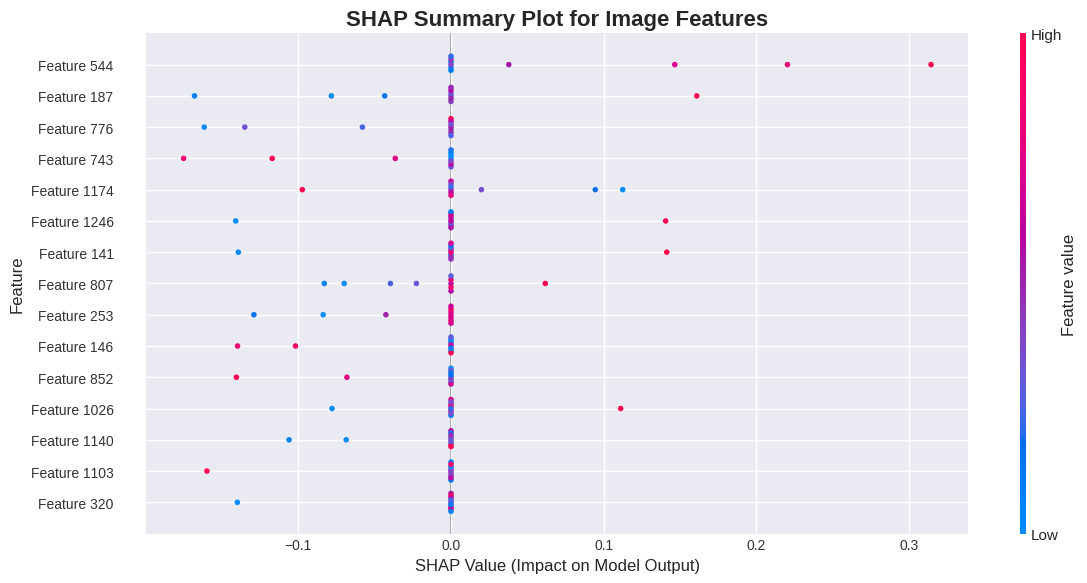

In [57]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Small background sample for SHAP
background = shap.sample(train_features, 10, random_state=42)

# Step 2: Create the SHAP KernelExplainer
explainer = shap.KernelExplainer(
    model=svm_model.decision_function,  # use decision_function since predict_proba is not available
    data=background
)

# Step 3: Compute SHAP values for a subset of test data
X_explain = test_features[:10]
shap_values = explainer.shap_values(X_explain)

# Step 4: Customize and plot SHAP summary (beeswarm style)
plt.style.use("seaborn-v0_8-darkgrid")  # optional: use a nicer plot style

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=[f'Feature {i}' for i in range(test_features.shape[1])],
    plot_size=(12, 6),        # Wider layout
    max_display=15,           # Show top 15 features only
    show=False                # Prevent auto-show so we can customize
)

# Step 5: Further customize the plot
plt.title("SHAP Summary Plot for Image Features", fontsize=16, weight='bold')
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


<ipython-input-58-0526acfc4ac2>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_features, palette=colors)


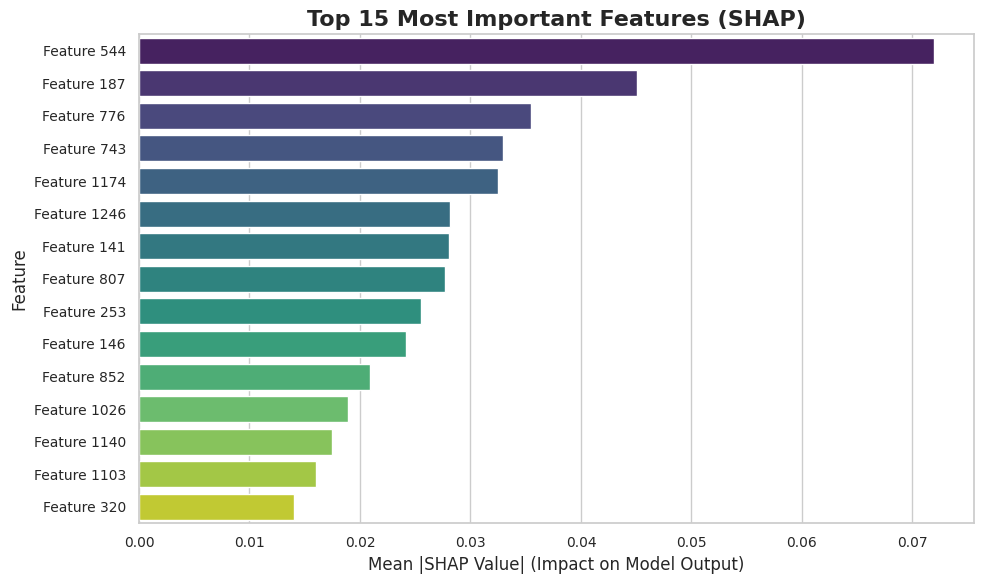

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Compute mean absolute SHAP values per feature
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

# Step 2: Get top 15 features
top_indices = np.argsort(mean_abs_shap)[-15:][::-1]
top_features = [f'Feature {i}' for i in top_indices]
top_values = mean_abs_shap[top_indices]

# Step 3: Create colorful bar plot
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Use a bright color palette
colors = sns.color_palette("viridis", len(top_features))

# Plot horizontal bars
sns.barplot(x=top_values, y=top_features, palette=colors)

# Step 4: Add labels and styling
plt.title("Top 15 Most Important Features (SHAP)", fontsize=16, weight='bold')
plt.xlabel("Mean |SHAP Value| (Impact on Model Output)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


visualiozation
whats after XAI how do we see the
then ADHD

In [44]:
pip install lime


In [59]:
from lime import lime_tabular
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.preprocessing import normalize
import numpy as np

# Step 1: Preprocess images
#X_train_prep = preprocess_input(X_train)
#X_test_prep = preprocess_input(X_test)

# Step 2: Extract features
#X_train_feat = base_model.predict(X_train_prep)
#X_test_feat = base_model.predict(X_test_prep)

# Step 3: Define a pseudo-probability function using decision_function
def decision_to_proba(X):
    decision = svm_model.decision_function(X)
    # Ensure 2D shape for binary classification
    if len(decision.shape) == 1:
        decision = np.vstack([-decision, decision]).T
    # Apply softmax to simulate probabilities
    exp = np.exp(decision - np.max(decision, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

# Step 4: Create LIME explainer
explainer = lime_tabular.LimeTabularExplainer(
    training_data=train_features,
    mode='classification',
    feature_names=[f'Feature {i}' for i in range(X_train_feat.shape[1])],
    class_names=['Not Churned', 'Churned'],  # Adjust as needed
    discretize_continuous=True,
    random_state=42
)

# Step 5: Choose a test sample to explain
i = 0
sample = test_features[i]

# Step 6: Generate explanation
explanation = explainer.explain_instance(
    data_row=sample,
    predict_fn=decision_to_proba,  # <-- Using our custom wrapper
    num_features=10
)

# Step 7: Visualize
explanation.show_in_notebook(show_table=True, show_all=False)


In [ ]:
# prompt: based on the results of the shap and lime what do I need to change in my dataset

# Based on the SHAP and LIME results, identify the most important features
# and their impact on the model's predictions.  The provided code already
# generates SHAP and LIME visualizations, but you need to *interpret* them.

# 1. Analyze SHAP Summary Plot:
#   - Identify features with high absolute SHAP values. These features have the
#     largest impact on the model's predictions.
#   - Look at the color of the points.  Red points indicate positive impact (pushing
#     predictions towards one class), blue points indicate negative impact (pushing
#     predictions towards the other class).
#   - Features consistently high and with a specific color indicate strong influence.

# 2. Analyze SHAP Feature Importance Plot (Bar Plot):
#   - This plot ranks features by their average absolute SHAP values. The features
#     at the top are the most important overall.
#   - This reinforces findings from the summary plot.

# 3. Analyze LIME Explanations:
#   - LIME explains individual predictions by showing which features contributed
#     most to that specific prediction.  Examine multiple explanations for various
#     samples to get a general sense of features' importance.
#   - Pay attention to the magnitude of the feature contributions (positive and negative).

# 4. Interpret and Act:
#   -  If certain features consistently appear at the top of both SHAP plots and have large contributions
#      in LIME explanations, they are very important to model performance.
#   -  If a feature is important but its impact is not always consistent (it changes from red to blue for example)
#      this means the feature itself is important, but more investigation is needed to understand its effect.
#   - Look at the feature's distribution and relationships with other features to try to understand this better.

#   Here are some possible actions based on your interpretation:
#     a) Feature Engineering:
#        - If a less important feature seems relevant based on domain expertise, consider engineering new features.
#        - Combine or transform features to improve their predictive power.
#     b) Data Cleaning/Preprocessing:
#        - Identify and address potential issues in the important features:
#           - Missing values: Impute or remove samples with missing values for important features.
#           - Outliers: Carefully examine and handle outliers in important features.
#           - Data inconsistencies: Correct inconsistencies.
#     c) Feature Selection:
#        - Consider dropping features with consistently low SHAP values and small LIME contributions if they
#          don't seem important based on domain knowledge.  (Use caution).
#     d) Model Adjustment:
#        - If certain features are overly influencing predictions, you might need to re-balance your dataset
#          or use regularization techniques.

# IMPORTANT NOTE:  Always consider your domain expertise when interpreting XAI results.
#  XAI methods can highlight patterns, but domain knowledge is needed for correct interpretation.


In [53]:
X_full = X_train.copy()  # Save the full 1280-feature MobileNet output before anything modifies it


In [60]:
print("SHAP input shape:", X_sample.shape)



SHAP input shape: (100, 224, 224, 3)
